# Metric — Multiple-Choice Answer Log-Likelihood (Acc_MC)

**This is the multiple-choice metric reported in the thesis.**

$$\mathrm{score}_{\theta}(a \mid q, c^{+}) = \frac{1}{|a|}\sum_{t}\log \pi_{\theta}\left(a_t \mid q, c^{+}, a_{<t}\right)$$

$$\hat{a} = \arg\max_{a \in \mathcal{A}} \mathrm{score}_{\theta}(a \mid q, c^{+}), \qquad \mathrm{Acc}_{\mathrm{MC}} = \frac{1}{N}\sum_{i}\mathbf{1}\!\left[\hat{a}_i = y^{+}_i\right]$$

Each candidate answer is scored by its **length-normalised log-likelihood**, teacher-forced under the relevant snippet (`_answer_logprobs_batch`), and the prediction is the highest-scoring candidate. No text is generated and no external judge is involved, so the measurement is deterministic.

Alongside accuracy the notebook reports AUROC, expected calibration error, per-option entropy and confidence statistics.

See `mc_choice_success_rate.ipynb` for a variant that scores the option *letter* instead of the answer text.

---

*Notation:* `q` query · `c+` relevant snippet · `c-` off-topic snippet from the same user · `y+` personalised answer · `y-` general answer


In [1]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !pip -q install -U datasets huggingface_hub transformers accelerate peft bitsandbytes matplotlib

    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive")
else:
    DRIVE_ROOT = Path(".")

if IN_COLAB:
    PP_ROOT = DRIVE_ROOT / "privacy_perserving_pllm"
else:
    _here = Path(".").resolve()
    PP_ROOT = next(
        (
            p for p in [_here, *_here.parents]
            if (p / "v2_personamem_persona_subsets").exists()
            or all((p / d).exists() for d in ("centralised", "evaluation", "fed_grad_avg", "zero_shot"))
        ),
        _here,
    )
SUBSET_NAME = "all_subset"
SUBSETS_DIR = PP_ROOT / "v2_personamem_persona_subsets"

OUTPUT_DIR = PP_ROOT / SUBSET_NAME / "v2_personamem_mc_answer_logprob_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Subset:", SUBSET_NAME)
print("Results will be saved to:", OUTPUT_DIR.resolve())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.9/774.9 kB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 775.8/775.8 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 156.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 42.6 MB/s eta 0:00:00
Mounted at /content/drive
Subset: all_subset
Results will be saved to: /content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_mc_answer_logprob_eval


In [2]:
import ast
import json
import random
from typing import Any, Dict, List

import pandas as pd
from transformers import AutoTokenizer

SEED = 42
random.seed(SEED)


def parse_user_query(raw):
    if isinstance(raw, dict):
        return str(raw.get("content", raw)).strip()
    if isinstance(raw, str):
        try:
            d = ast.literal_eval(raw)
            if isinstance(d, dict):
                return str(d.get("content", raw)).strip()
        except (ValueError, SyntaxError):
            pass
        return raw.strip()
    return str(raw).strip()


def parse_incorrect_answers(raw):
    if isinstance(raw, list):
        return [str(x) for x in raw]
    if hasattr(raw, "tolist"):
        return [str(x) for x in raw.tolist()]
    if isinstance(raw, str):
        try:
            val = ast.literal_eval(raw)
            if isinstance(val, list):
                return [str(x) for x in val]
        except (ValueError, SyntaxError):
            pass
        return [raw]
    return []

def get_snippet(row):
    val = row.get("related_conversation_snippet")
    if val is None:
        return ""
    return str(val).strip()

In [3]:
def load_subset(name, subsets_dir=SUBSETS_DIR):
    """Load a persona subset (ids + train/val rows) saved by create_persona_subsets.ipynb."""
    subset_dir = Path(subsets_dir) / name
    if not subset_dir.exists():
        raise FileNotFoundError(f"Subset not found: {subset_dir}. Run create_persona_subsets.ipynb first.")
    with open(subset_dir / "personas.json", "r", encoding="utf-8") as f:
        persona_ids = [int(p) for p in json.load(f)]
    tr = pd.read_parquet(subset_dir / "train.parquet")
    va = pd.read_parquet(subset_dir / "val.parquet")
    return sorted(persona_ids), tr, va


CLIENT_PERSONAS, train_df, val_df = load_subset(SUBSET_NAME)
NUM_CLIENTS = len(CLIENT_PERSONAS)
print(f"Subset '{SUBSET_NAME}': {NUM_CLIENTS} personas | train rows: {len(train_df):,} | val rows: {len(val_df):,}")

Subset 'all_subset': 150 personas | train rows: 3,870 | val rows: 714


In [4]:
import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc

import torch
from peft import PeftModel
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "Qwen/Qwen3-0.6B"
MAX_SNIPPET_TOKENS = 1024
MAX_SEQ_LEN = 2048

model_tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if model_tok.pad_token is None:
    model_tok.pad_token = model_tok.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

def build_system_prompt():
    return (
        "You are a personalised assistant. Use the conversation snippet to find "
        "information or connections relevant to the question, then provide the answer."
    )

def truncate_snippet(snippet, max_tokens):
    ids = model_tok(snippet, add_special_tokens=False)["input_ids"]
    if len(ids) <= max_tokens:
        return snippet
    return model_tok.decode(ids[-max_tokens:], skip_special_tokens=True)

def build_user_content(row):
    snippet = truncate_snippet(get_snippet(row), MAX_SNIPPET_TOKENS)
    return (
        "Relevant snippet from our earlier conversation:\n"
        f"{snippet}\n\n"
        f"{parse_user_query(row['user_query'])}"
    )

def load_model(adapter_dir=None):
    """adapter_dir=None -> zero-shot base model; else base model + LoRA adapter."""
    base = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME, quantization_config=bnb_config, device_map="auto",
        trust_remote_code=True, attn_implementation="sdpa",
    )
    base.config.use_cache = True
    model = base if adapter_dir is None else PeftModel.from_pretrained(base, str(adapter_dir))
    model.eval()
    return model

def free_model(model):
    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

In [5]:
SUBSET_DIR = PP_ROOT / SUBSET_NAME
ADAPTER_EPOCH = 3
_ADAPTER_NAME = f"adapter_epoch_{ADAPTER_EPOCH}" if ADAPTER_EPOCH is not None else "adapter"
_G = lambda *parts: SUBSET_DIR.joinpath(*parts) / "global" / _ADAPTER_NAME
_G5 = lambda name: (
    PP_ROOT / "fed_grad_avg" / "fed_grad_avg_5_set" / SUBSET_NAME / name / "global" / _ADAPTER_NAME
)

MODELS_TO_EVAL = {
    "zero_shot": None,
    "centralized_sft": _G("v2_personamem_centralized_sft_snippet"),
    "centralized_orpo": _G("v2_personamem_centralized_orpo_snippet"),
    "centralized_ctx_contrast_orpo": _G("v2_personamem_centralized_ctx_contrast_orpo_snippet"),
    "centralized_combined_orpo": _G("v2_personamem_centralized_combined_orpo_snippet"),
    "centralized_gen_edit_snippet": _G("v2_personamem_centralized_gen_edit_snippet"),
    "federated_sft_gradavg": _G("v2_personamem_federated_sft_gradavg_snippet"),
    "federated_orpo_gradavg": _G("v2_personamem_federated_orpo_gradavg_snippet"),
    "federated_ctx_contrast_orpo_gradavg": _G("v2_personamem_federated_ctx_contrast_orpo_gradavg_snippet"),
    "federated_combined_orpo_gradavg": _G("v2_personamem_federated_combined_orpo_gradavg_snippet"),
    "federated_gen_edit_gradavg_snippet": _G("v2_personamem_federated_gen_edit_gradavg_snippet"),
}

MAX_OPTIONS = 4
EVAL_BATCH_SIZE = 16

LETTERS = [chr(ord("A") + i) for i in range(MAX_OPTIONS)]

PERSONA_SYSTEM: Dict[int, str] = {}
for pid in CLIENT_PERSONAS:
    p_train = train_df[train_df["persona_id"] == pid].reset_index(drop=True)
    PERSONA_SYSTEM[int(pid)] = build_system_prompt()

print("Models:", list(MODELS_TO_EVAL))
print("Built per-persona system prompts:", len(PERSONA_SYSTEM))
for k, v in MODELS_TO_EVAL.items():
    print(f"  {k}: {v}")

Models: ['zero_shot', 'centralized_sft', 'centralized_orpo', 'centralized_ctx_contrast_orpo', 'centralized_combined_orpo', 'centralized_gen_edit_snippet', 'federated_sft_gradavg', 'federated_orpo_gradavg', 'federated_ctx_contrast_orpo_gradavg', 'federated_combined_orpo_gradavg', 'federated_gen_edit_gradavg_snippet']
Built per-persona system prompts: 150
  zero_shot: None
  centralized_sft: /content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_centralized_sft_snippet/global/adapter_epoch_3
  centralized_orpo: /content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_centralized_orpo_snippet/global/adapter_epoch_3
  centralized_ctx_contrast_orpo: /content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_centralized_ctx_contrast_orpo_snippet/global/adapter_epoch_3
  centralized_combined_orpo: /content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_centralized_combined_orpo_snippet/global/adapter_epoch_3
  centralized_gen_edit_s

In [6]:
_rng = random.Random(SEED)
MC_ITEMS: List[Dict[str, Any]] = []
skipped = 0
for pid in CLIENT_PERSONAS:
    p_val = val_df[val_df["persona_id"] == pid].reset_index(drop=True)
    for ex_id, r in p_val.iterrows():
        row = r.to_dict()
        correct = str(row.get("correct_answer", "")).strip()
        incs = [s.strip() for s in parse_incorrect_answers(row.get("incorrect_answers")) if str(s).strip()]
        incs = [s for s in incs if s != correct][: MAX_OPTIONS - 1]
        if not correct or not incs:
            skipped += 1
            continue
        texts = [correct] + incs
        _rng.shuffle(texts)
        letters = LETTERS[: len(texts)]
        correct_letter = letters[texts.index(correct)]
        MC_ITEMS.append({
            "persona_id": int(pid),
            "ex_id": int(ex_id),
            "row": row,
            "options": list(zip(letters, texts)),
            "correct_letter": correct_letter,
            "num_options": len(texts),
        })

print(f"Built {len(MC_ITEMS)} MC items (skipped {skipped} with no distractors).")
opt_counts = pd.Series([it["num_options"] for it in MC_ITEMS]).value_counts().sort_index()
print("Options-per-question distribution:", dict(opt_counts))
print("Random-guess baseline (mean 1/num_options):",
      round(float(pd.Series([1.0 / it["num_options"] for it in MC_ITEMS]).mean()), 4))

Built 714 MC items (skipped 0 with no distractors).
Options-per-question distribution: {4: np.int64(714)}
Random-guess baseline (mean 1/num_options): 0.25


In [7]:
from collections import defaultdict

import numpy as np
from tqdm.auto import tqdm

def _rankdata_avg(a):
    a = np.asarray(a, dtype=float)
    order = a.argsort(kind="mergesort")
    ranks = np.empty(len(a), dtype=float)
    sa = a[order]
    i = 0
    while i < len(a):
        j = i
        while j + 1 < len(a) and sa[j + 1] == sa[i]:
            j += 1
        ranks[order[i:j + 1]] = (i + j) / 2.0 + 1.0
        i = j + 1
    return ranks

def auroc(pos, neg):
    """AUROC = P(random positive scores higher than random negative), tie-aware."""
    pos = np.asarray(pos, dtype=float); neg = np.asarray(neg, dtype=float)
    pos = pos[~np.isnan(pos)]; neg = neg[~np.isnan(neg)]
    n1, n2 = len(pos), len(neg)
    if n1 == 0 or n2 == 0:
        return float("nan")
    r = _rankdata_avg(np.concatenate([pos, neg]))
    return float((r[:n1].sum() - n1 * (n1 + 1) / 2.0) / (n1 * n2))

def expected_calibration_error(conf, correct, n_bins=10):
    conf = pd.to_numeric(pd.Series(conf), errors="coerce").values
    correct = np.asarray(correct, dtype=float)
    mask = ~np.isnan(conf)
    conf, correct = conf[mask], correct[mask]
    if len(conf) == 0:
        return float("nan")
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece, n = 0.0, len(conf)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        sel = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
        if sel.sum() == 0:
            continue
        ece += (sel.sum() / n) * abs(correct[sel].mean() - conf[sel].mean())
    return float(ece)

@torch.no_grad()
def _answer_logprobs_batch(model, prompts, answers):
    """Length-normalised log-prob of each answer given its prompt (teacher forced)."""
    enc_p = [model_tok(p, add_special_tokens=False)["input_ids"] for p in prompts]
    enc_a = [model_tok(a, add_special_tokens=False)["input_ids"] for a in answers]
    seqs, spans = [], []
    for p, a in zip(enc_p, enc_a):
        if len(p) + len(a) > MAX_SEQ_LEN:
            p = p[-(MAX_SEQ_LEN - len(a)):] if MAX_SEQ_LEN > len(a) else []
        seqs.append(p + a)
        spans.append((len(p), len(a)))
    maxlen = max(len(s) for s in seqs)
    pad_id = model_tok.pad_token_id
    input_ids = torch.full((len(seqs), maxlen), pad_id, dtype=torch.long)
    attn = torch.zeros((len(seqs), maxlen), dtype=torch.long)
    for i, s in enumerate(seqs):
        input_ids[i, :len(s)] = torch.tensor(s, dtype=torch.long)
        attn[i, :len(s)] = 1
    input_ids = input_ids.to(model.device); attn = attn.to(model.device)
    logprobs = torch.log_softmax(model(input_ids=input_ids, attention_mask=attn).logits.float(), dim=-1)
    out = []
    for i, (p_len, a_len) in enumerate(spans):
        if a_len == 0:
            out.append(float("-inf")); continue
        pos = list(range(p_len - 1, p_len + a_len - 1))
        tgt = torch.tensor(seqs[i][p_len:p_len + a_len], device=model.device)
        lp = logprobs[i, pos, :].gather(-1, tgt.unsqueeze(-1)).squeeze(-1)
        out.append(float(lp.mean()))
    return out

def evaluate_model(name, adapter):
    model = load_model(adapter)
    model.eval()
    model.config.use_cache = True
    model_tok.padding_side = "right"

    prompts, answers, owner = [], [], []
    for ii, it in enumerate(MC_ITEMS):
        base = model_tok.apply_chat_template(
            [{"role": "system", "content": PERSONA_SYSTEM[it["persona_id"]]},
             {"role": "user", "content": build_user_content(it["row"])}],
            tokenize=False, add_generation_prompt=True)
        for letter, text in it["options"]:
            prompts.append(base); answers.append(str(text)); owner.append((ii, letter))

    scores = []
    for s in tqdm(range(0, len(prompts), EVAL_BATCH_SIZE), desc=name):
        scores.extend(_answer_logprobs_batch(model, prompts[s:s + EVAL_BATCH_SIZE], answers[s:s + EVAL_BATCH_SIZE]))
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    by_item = defaultdict(dict)
    for (ii, letter), sc in zip(owner, scores):
        by_item[ii][letter] = sc

    records = []
    for ii, it in enumerate(MC_ITEMS):
        d = by_item[ii]
        letters = list(d.keys())
        opt = torch.softmax(torch.tensor([d[L] for L in letters]), dim=-1)
        probs = {L: float(opt[k]) for k, L in enumerate(letters)}
        pred = max(d, key=d.get)
        ordered = sorted(probs.values(), reverse=True)
        cl = it["correct_letter"]
        records.append({
            "model": name, "persona_id": it["persona_id"], "ex_id": it["ex_id"],
            "num_options": it["num_options"], "correct_letter": cl, "pred_letter": pred,
            "correct": bool(pred == cl),
            "p_chosen": probs[pred], "p_correct": probs.get(cl, float("nan")),
            "margin": ordered[0] - (ordered[1] if len(ordered) > 1 else 0.0),
            "entropy": float(-(opt * torch.log(opt.clamp_min(1e-12))).sum()),
            "logprob_correct": d.get(cl, float("nan")), "logprob_chosen": d[pred],
            "option_probs": json.dumps(probs),
        })
    free_model(model)
    return pd.DataFrame(records)

In [8]:
all_preds = []
summary_rows = []
per_persona_rows = []

for name, adapter in MODELS_TO_EVAL.items():
    if adapter is not None and not Path(adapter).exists():
        print(f"[skip] {name}: adapter not found at {adapter}")
        continue
    print(f"\n=== {name} (adapter={adapter}) ===")
    df = evaluate_model(name, adapter)
    all_preds.append(df)

    model_dir = OUTPUT_DIR / name
    model_dir.mkdir(parents=True, exist_ok=True)
    df.to_csv(model_dir / "mc_predictions.csv", index=False)

    corr = df["correct"].values.astype(bool)

    def _m(series):
        return float(pd.to_numeric(series, errors="coerce").mean())

    conf_correct = _m(df.loc[corr, "p_chosen"]) if corr.any() else float("nan")
    conf_wrong = _m(df.loc[~corr, "p_chosen"]) if (~corr).any() else float("nan")
    summary_rows.append({
        "model": name,
        "n": int(len(df)),
        "success_rate": float(df["correct"].mean()),
        "random_baseline": float((1.0 / df["num_options"]).mean()),
        "mean_p_correct": _m(df["p_correct"]),
        "mean_p_chosen": _m(df["p_chosen"]),
        "mean_margin": _m(df["margin"]),
        "mean_entropy": _m(df["entropy"]),
        "mean_logprob_correct": _m(df["logprob_correct"]),
        "conf_when_correct": conf_correct,
        "conf_when_wrong": conf_wrong,
        "conf_gap": conf_correct - conf_wrong,
        "auroc_conf_vs_correct": auroc(df.loc[corr, "p_chosen"].values, df.loc[~corr, "p_chosen"].values),
        "ece": expected_calibration_error(df["p_chosen"], df["correct"]),
    })

    pp = df.groupby("persona_id")["correct"].mean().reset_index().rename(columns={"correct": "success_rate"})
    pp["model"] = name
    pp.to_csv(model_dir / "per_persona_success.csv", index=False)
    per_persona_rows.append(pp)

    print(f"  success rate: {df['correct'].mean():.4f}  (n={len(df)})")

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUTPUT_DIR / "success_rate_summary.csv", index=False)
summary_df.to_json(OUTPUT_DIR / "success_rate_summary.json", orient="records", indent=2)
if all_preds:
    pd.concat(all_preds, ignore_index=True).to_csv(OUTPUT_DIR / "all_mc_predictions.csv", index=False)
if per_persona_rows:
    pd.concat(per_persona_rows, ignore_index=True).to_csv(OUTPUT_DIR / "per_persona_success_all_models.csv", index=False)

with open(OUTPUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump({
        "method": "mc_answer_logprob",
        "prompt_format": "snippet + question, answer generated directly, no Facts/Answer marker",
        "subset": SUBSET_NAME,
        "split": "val",
        "max_options": MAX_OPTIONS,
        "n_items": len(MC_ITEMS),
        "models": list(MODELS_TO_EVAL),
        "seed": SEED,
    }, f, indent=2)

print("\n=== Answer-likelihood MC success rate (val, subset_0) ===")
print(summary_df.to_string(index=False))


=== zero_shot (adapter=None) ===


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

...

federated_combined_orpo_gradavg:   0%|          | 0/179 [00:00<?, ?it/s]

  success rate: 0.4384  (n=714)

=== federated_gen_edit_gradavg_snippet (adapter=/content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_federated_gen_edit_gradavg_snippet/global/adapter_epoch_3) ===


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

federated_gen_edit_gradavg_snippet:   0%|          | 0/179 [00:00<?, ?it/s]

  success rate: 0.3711  (n=714)

=== Answer-likelihood MC success rate (val, subset_0) ===
                              model   n  success_rate  random_baseline  mean_p_correct  mean_p_chosen  mean_margin  mean_entropy  mean_logprob_correct  conf_when_correct  conf_when_wrong  conf_gap  auroc_conf_vs_correct      ece
                          zero_shot 714      0.259104             0.25        0.267470       0.379639     0.119421      1.313850             -3.519316           0.386448         0.377258  0.009189               0.513146 0.122747
                    centralized_sft 714      0.380952             0.25        0.301010       0.373641     0.102922      1.309493             -2.461914           0.386193         0.365917  0.020276               0.570510 0.013977
                   centralized_orpo 714      0.477591             0.25        0.342826       0.407982     0.139222      1.261266             -2.505674           0.442072         0.376816  0.065256               0.648227 0.

In [ ]:
==
                       model   n  success_rate  random_baseline  mean_p_correct  mean_p_chosen  mean_margin  mean_entropy  mean_logprob_correct  conf_when_correct  conf_when_wrong  conf_gap  auroc_conf_vs_correct      ece
                   zero_shot 714      0.259104             0.25        0.267470       0.379639     0.119421      1.313850             -3.519316           0.386448         0.377258  0.009189               0.513146 0.122747
centralized_gen_edit_snippet 714      0.406162             0.25        0.308376       0.384172     0.112504      1.297906             -2.636764           0.395121         0.376683  0.018438               0.551936 0.029043

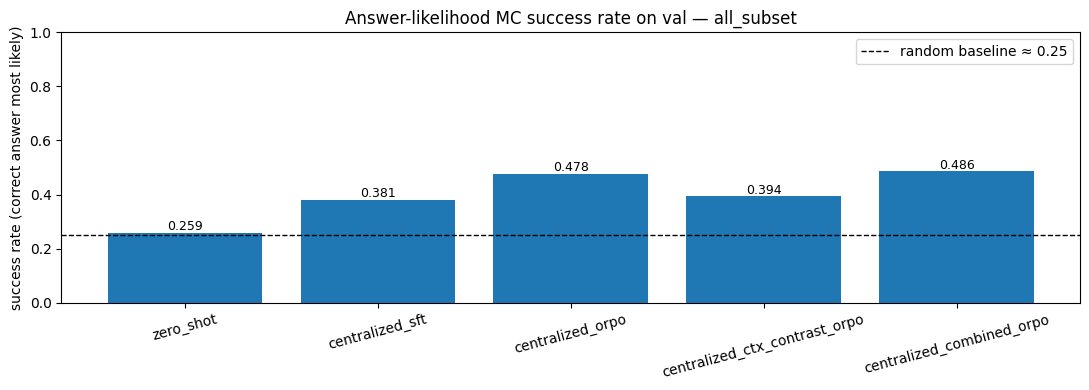

Saved: /content/drive/MyDrive/privacy_perserving_pllm/all_subset/v2_personamem_mc_answer_logprob_eval/fig_success_rate.png


In [ ]:
import matplotlib.pyplot as plt

if len(summary_df):
    fig, ax = plt.subplots(figsize=(1.6 * len(summary_df) + 3, 4))
    bars = ax.bar(summary_df["model"], summary_df["success_rate"], color="tab:blue")
    base = float(summary_df["random_baseline"].mean())
    ax.axhline(base, color="k", ls="--", lw=1, label=f"random baseline \u2248 {base:.2f}")
    ax.set_ylim(0, 1)
    ax.set_ylabel("success rate (correct answer most likely)")
    ax.set_title(f"Answer-likelihood MC success rate on val \u2014 {SUBSET_NAME}")
    ax.tick_params(axis="x", rotation=15)
    for b, v in zip(bars, summary_df["success_rate"]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "fig_success_rate.png", dpi=150)
    plt.show()
    print("Saved:", OUTPUT_DIR / "fig_success_rate.png")
else:
    print("No models were evaluated (check adapter paths in MODELS_TO_EVAL).")

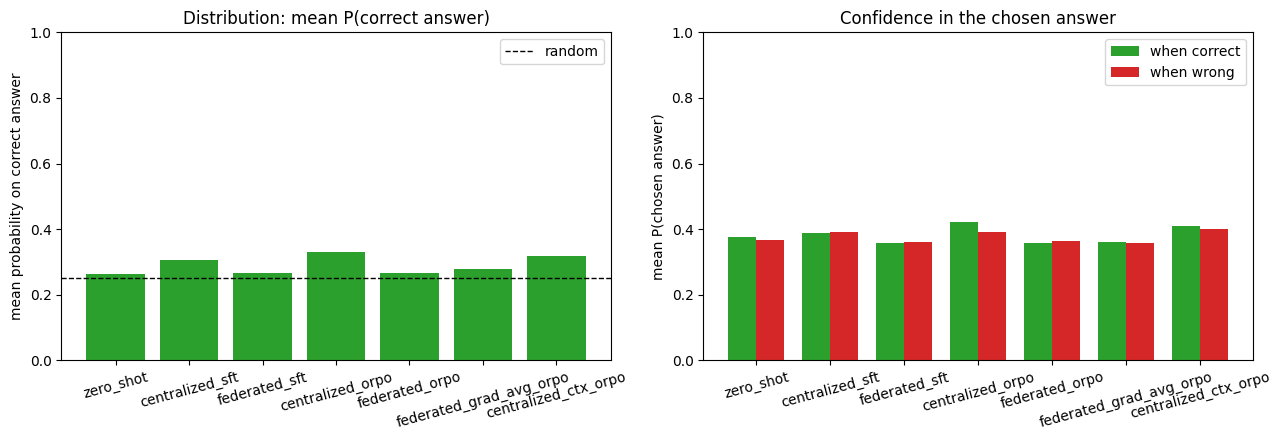

Saved: /content/drive/MyDrive/privacy_perserving_pllm/subset_0/v2_personamem_mc_answer_logprob_eval/fig_token_confidence.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if len(summary_df):
    S = summary_df
    x = np.arange(len(S)); w = 0.38
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

    ax[0].bar(S["model"], S["mean_p_correct"], color="tab:green")
    ax[0].axhline(float(S["random_baseline"].mean()), color="k", ls="--", lw=1, label="random")
    ax[0].set_ylim(0, 1)
    ax[0].set_title("Distribution: mean P(correct answer)")
    ax[0].set_ylabel("mean probability on correct answer")
    ax[0].tick_params(axis="x", rotation=15); ax[0].legend()

    ax[1].bar(x - w / 2, S["conf_when_correct"], w, label="when correct", color="tab:green")
    ax[1].bar(x + w / 2, S["conf_when_wrong"], w, label="when wrong", color="tab:red")
    ax[1].set_xticks(x); ax[1].set_xticklabels(S["model"], rotation=15)
    ax[1].set_ylim(0, 1)
    ax[1].set_title("Confidence in the chosen answer")
    ax[1].set_ylabel("mean P(chosen answer)"); ax[1].legend()

    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "fig_token_confidence.png", dpi=150); plt.show()
    print("Saved:", OUTPUT_DIR / "fig_token_confidence.png")

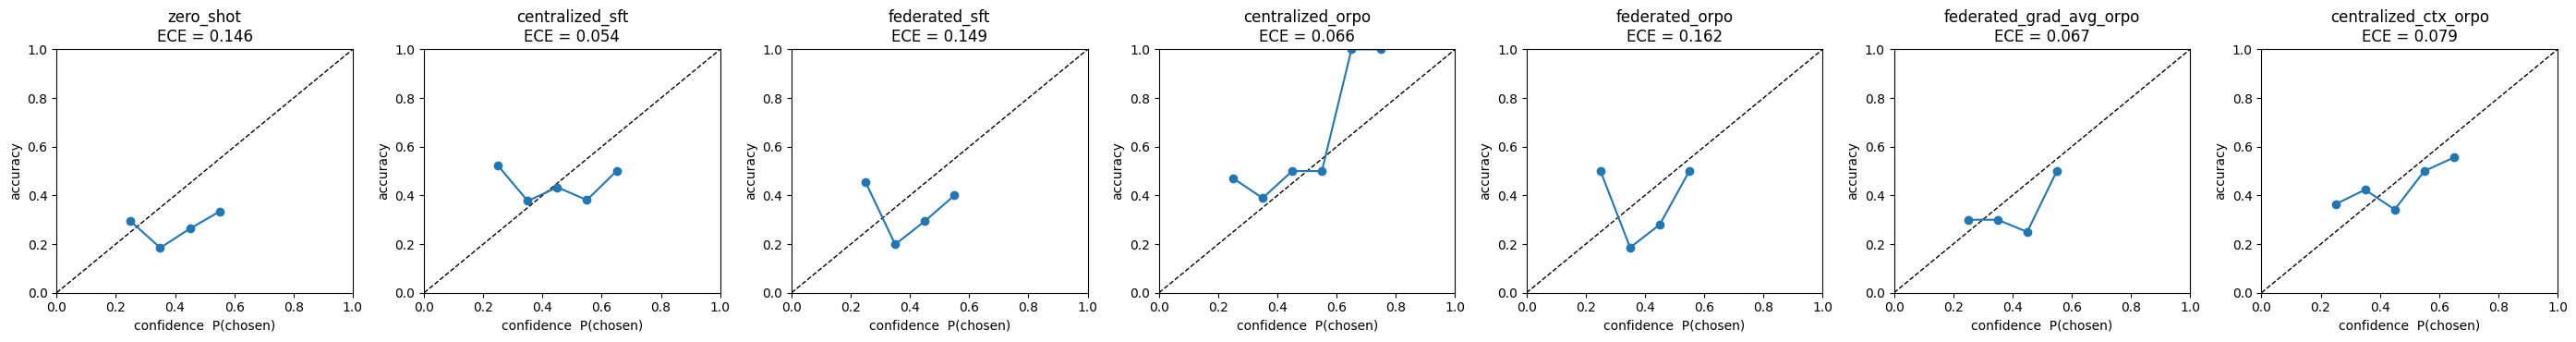

Saved: /content/drive/MyDrive/privacy_perserving_pllm/subset_0/v2_personamem_mc_answer_logprob_eval/fig_reliability.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if all_preds:
    big = pd.concat(all_preds, ignore_index=True)
    models = [m for m in MODELS_TO_EVAL if (big["model"] == m).any()]
    n_bins = 10
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    centers = (bins[:-1] + bins[1:]) / 2
    ncol = max(1, len(models))
    fig, axes = plt.subplots(1, ncol, figsize=(4 * ncol, 3.8), squeeze=False)
    for j, m in enumerate(models):
        d = big[big["model"] == m]
        conf = pd.to_numeric(d["p_chosen"], errors="coerce").values
        corr = d["correct"].values.astype(float)
        accs = []
        for i in range(n_bins):
            lo, hi = bins[i], bins[i + 1]
            sel = (conf > lo) & (conf <= hi) if i > 0 else (conf >= lo) & (conf <= hi)
            accs.append(corr[sel].mean() if sel.sum() > 0 else np.nan)
        a = axes[0][j]
        a.plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
        a.plot(centers, accs, marker="o", color="tab:blue")
        ece_val = float(summary_df.loc[summary_df["model"] == m, "ece"].iloc[0])
        a.set_title(f"{m}\nECE = {ece_val:.3f}")
        a.set_xlabel("confidence  P(chosen)"); a.set_ylabel("accuracy")
        a.set_xlim(0, 1); a.set_ylim(0, 1)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "fig_reliability.png", dpi=150); plt.show()
    print("Saved:", OUTPUT_DIR / "fig_reliability.png")